In [3]:
# TensorFlow нұсқасын тексеру
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

# Керек кітапханалар
import numpy as np
import matplotlib.pyplot as plt
import time

TensorFlow version: 2.19.0


x_train shape: (50000, 32, 32, 3)
x_test shape : (10000, 32, 32, 3)


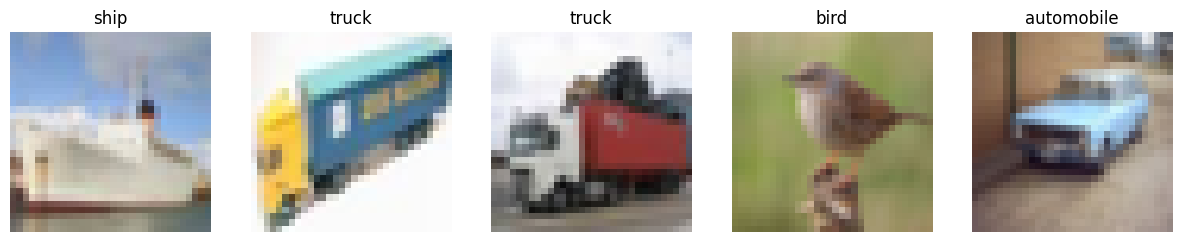

In [4]:
from tensorflow.keras.datasets import cifar10

# 1) Датасетті жүктеу
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("x_train shape:", x_train.shape)  # (50000, 32, 32, 3)
print("x_test shape :", x_test.shape)   # (10000, 32, 32, 3)

# 2) Нормализация (0..255 -> 0..1)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# 3) Label-дерді вектордан бір өлшемге келтіру
y_train = y_train.flatten()
y_test = y_test.flatten()

# 4) Класс атаулары
class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

# 5) Кездейсоқ 5 сурет көрсету
idx = np.random.choice(len(x_train), 5, replace=False)

plt.figure(figsize=(15,3))
for i, id_ in enumerate(idx):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[id_])
    plt.title(class_names[y_train[id_]])
    plt.axis("off")
plt.show()

In [5]:
from tensorflow.keras import layers, models

basic_cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # CIFAR-10 -> 10 класс
])

basic_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
reg_cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

reg_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

reg_cnn.summary()

# Оқыту уақытын өлшеу
start_time = time.time()

history_reg = reg_cnn.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=10,          # талап бойынша кемінде 10
    batch_size=64,
    verbose=1
)

scratch_train_time = time.time() - start_time
print(f"\nScratch CNN оқу уақыты: {scratch_train_time:.2f} секунд")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,218 (1.37 MB)

 Trainable params: 357,514 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 124s 193ms/step - accuracy: 0.4240 - loss: 1.6585 - val_accuracy: 0.4228 - val_loss: 1.6963
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 183ms/step - accuracy: 0.5584 - loss: 1.2367 - val_accuracy: 0.5902 - val_loss: 1.1515
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 182ms/step - accuracy: 0.6222 - loss: 1.0656 - val_accuracy: 0.6275 - val_loss: 1.0743
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 112s 179ms/step - accuracy: 0.6611 - loss: 0.9646 - val_accuracy: 0.4896 - val_loss: 1.6778
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 112s 180ms/step - accuracy: 0.6825 - loss: 0.9010 - val_accuracy: 0.7012 - val_loss: 0.8537
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 187ms/step - accuracy: 0.7029 - loss: 0.8432 - val_accuracy: 0.7169 - val_loss: 0.8056
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 182ms/step - accuracy: 0.7172 - loss: 0.8039 - val_accuracy: 0.6965 - val_loss: 0.9190
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 117s 187ms/step - accuracy: 0.7305 -

Scratch CNN Test Loss: 1.1809
Scratch CNN Test Accuracy: 0.6231


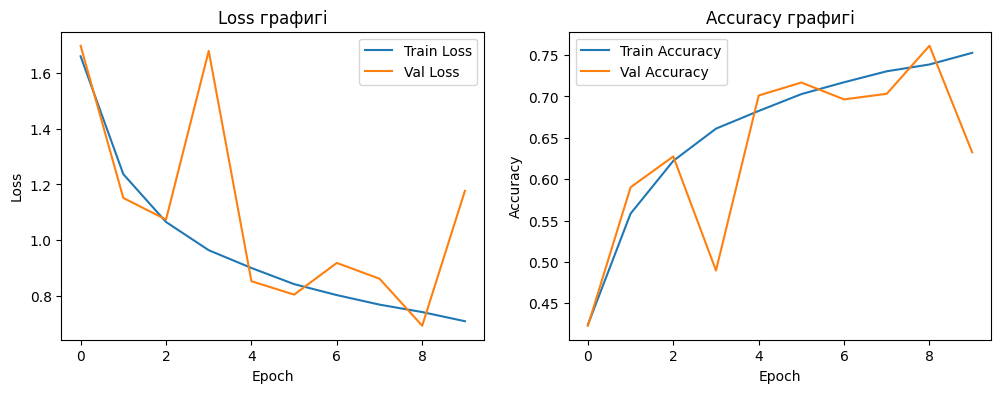

Байқау: overfitting белгілері бар (train acc >> val acc).


In [7]:
# 1) Тест дәлдігі
test_loss, test_acc = reg_cnn.evaluate(x_test, y_test, verbose=0)
print(f"Scratch CNN Test Loss: {test_loss:.4f}")
print(f"Scratch CNN Test Accuracy: {test_acc:.4f}")

# 2) Графиктер
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history_reg.history['loss'], label='Train Loss')
plt.plot(history_reg.history['val_loss'], label='Val Loss')
plt.title('Loss графигі')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_reg.history['accuracy'], label='Train Accuracy')
plt.plot(history_reg.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy графигі')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# 3) Қарапайым талдау (автоматты)
if history_reg.history['accuracy'][-1] - history_reg.history['val_accuracy'][-1] > 0.08:
    print("Байқау: overfitting белгілері бар (train acc >> val acc).")
else:
    print("Байқау: overfitting қатты байқалмайды немесе қалыпты деңгейде.")

In [8]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import Model

# Transfer learning үшін көшірме (preprocess_input қажет)
x_train_tl = (x_train * 255.0).copy()  # preprocess_input 0..255 масштабын күтеді
x_test_tl  = (x_test * 255.0).copy()

x_train_tl = preprocess_input(x_train_tl)
x_test_tl  = preprocess_input(x_test_tl)

# Базалық модель (ImageNet салмақтары)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

# Негізгі қабаттарды freeze
base_model.trainable = False

# Жаңа классификатор
inputs = layers.Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

tl_model = Model(inputs, outputs)

tl_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()

start_time = time.time()

history_tl = tl_model.fit(
    x_train_tl, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)

transfer_train_time = time.time() - start_time
print(f"\nTransfer Learning оқу уақыты: {transfer_train_time:.2f} секунд")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 281ms/step - accuracy: 0.5206 - loss: 2.0302 - val_accuracy: 0.6222 - val_loss: 1.2586
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 263ms/step - accuracy: 0.5921 - loss: 1.3992 - val_accuracy: 0.6280 - val_loss: 1.2164
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 165s 264ms/step - accuracy: 0.6032 - loss: 1.3101 - val_accuracy: 0.6399 - val_loss: 1.1639
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 169s 270ms/step - accuracy: 0.6132 - loss: 1.2906 - val_accuracy: 0.6232 - val_loss: 1.2138
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 208s 279ms/step - accuracy: 0.6140 - loss: 1.2897 - val_accuracy: 0.6257 - val_loss: 1.2353
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 263ms/step - accuracy: 0.6125 - loss: 1.3057 - val_accuracy: 0.6333 - val_loss: 1.2513
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 212s 279ms/step - accuracy: 0.6140 - loss: 1.2942 - val_accuracy: 0.6193 - val_loss: 1.2912
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 204s 282ms/step - accuracy: 0.6148 -

In [9]:
# Transfer model test
tl_test_loss, tl_test_acc = tl_model.evaluate(x_test_tl, y_test, verbose=0)
print(f"Transfer Model Test Loss: {tl_test_loss:.4f}")
print(f"Transfer Model Test Accuracy: {tl_test_acc:.4f}")

# Салыстыру кестесі
print("\n=== НӘТИЖЕ САЛЫСТЫРУ ===")
print(f"1) Scratch CNN   -> Accuracy: {test_acc:.4f},   Time: {scratch_train_time:.2f} sec")
print(f"2) Transfer CNN  -> Accuracy: {tl_test_acc:.4f}, Time: {transfer_train_time:.2f} sec")

if tl_test_acc > test_acc:
    print("Қорытынды: Transfer Learning дәлдігі жоғары.")
else:
    print("Қорытынды: Бұл конфигурацияда Scratch CNN жақсырақ немесе шамалас нәтиже берді.")

Transfer Model Test Loss: 1.2372
Transfer Model Test Accuracy: 0.6355

=== НӘТИЖЕ САЛЫСТЫРУ ===
1) Scratch CNN   -> Accuracy: 0.6231,   Time: 1184.40 sec
2) Transfer CNN  -> Accuracy: 0.6355, Time: 1807.91 sec
Қорытынды: Transfer Learning дәлдігі жоғары.


Қорытынды сұрақтарға қысқа жауап:
1) Conv2D фильтрлері нені таниды?
Алғашқы қабаттар: қарапайым белгілер (жиек, бұрыш, түс контрастары).

Терең қабаттар: күрделі паттерндер (текстура, бөлшектер, объект бөліктері).

Ең соңғы қабаттарға қарай: жоғары деңгейлі семантикалық белгілер (мысалы, жануар беті, дөңгелек, киім пішіні).

2) MaxPooling мақсаты қандай?
Feature map өлшемін кішірейтеді → есептеу жүктемесі азаяды.

Ең маңызды белгілерді қалдырады.

Кішігірім жылжу/деформацияға төзімділікті арттырады (translation invariance).

3) Неге Transfer Learning тиімді?
ImageNet-та үйренген әмбебап визуал белгілерді қайта қолданады.

Шағын датасетте тезірек және тұрақтырақ үйренеді.

Нөлден бастап оқытудан көбіне жақсырақ нәтиже береді (әсіресе epoch аз болса).